In [1]:
import numpy as np
import polars as pl
from matplotlib import pyplot as plt

In [2]:
def generate_sinemix(train, val, test, n):
    N = train + val + test

    T = 100 // n
    rng = np.random.default_rng(seed=42)
    a, b = rng.random((2, N)) * 4 * np.pi + 2 * np.pi

    xs = np.linspace(0, 1, 100)
    y1 = np.sin(xs[None, :T] * a[:, None])

    # c makes it continuous
    c = xs[None, T - 1] * (a - b)[:, None]

    y2 = np.sin(xs[None, T:] * b[:, None] + c)

    ys = np.concatenate([y1, y2], axis=1)

    return (
        pl.DataFrame(
            {
                "time": xs[None].repeat(N, 0).tolist(),
                "y": ys.tolist(),
                "target": a.tolist(),
            }
        )
        .with_row_index()
        .with_columns(
            split=pl.when(pl.col("index") < train)
            .then(pl.lit("train"))
            .when(pl.col("index") < train + val)
            .then(pl.lit("val"))
            .otherwise(pl.lit("test"))
        )
        .drop("index")
    )

In [4]:
df = generate_sinemix(1024, 32, 32, 2)
df.write_parquet("/mnt/data/preprocessed/sinemix2.parquet")


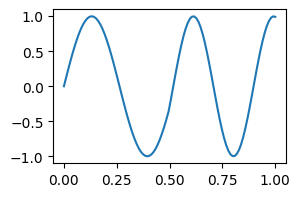

In [18]:
plt.figure(figsize=(3, 2))
xs, ys = df.row(9)[:2]
plt.plot(xs, ys)
plt.savefig("/app/assets/sinemix.pdf")